In [37]:
import numpy as np
np.random.seed(167834359)
import pandas as pd
import scipy.stats as stats
from scipy.special import gamma
import scipy.integrate as integrate
import tqdm

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })

from astropy.time import Time
from nmma.core.conversion import BNSEjectaFitting
msol_to_erg = 1.787624e54
Mpc_to_cm = 3.8057e24

# load EOS
m_val, r_val, l_val = np.loadtxt("../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
r16 = np.interp(1.6, m_val, r_val)

df_narrow_grb = pd.read_csv("./full_narrow_grb_parameters.dat", sep=" ")
df_wide_grb = pd.read_csv("./full_wide_grb_parameters.dat", sep=" ")

In [4]:
def eta(chi_BH):
    OmegaH = chi_BH / (2*(1+np.sqrt(1-chi_BH**2)))
    return OmegaH**2 * (1+1.38*OmegaH**2-9.2*OmegaH**4)

def draw_thetaCore(n):
    theta_c = np.zeros(n)
    mask = np.random.choice([True, False], replace=True, size=n)
    theta_c[mask] = stats.truncnorm(loc=6.1, scale=3.2, a=-6.1/3.2, b=0).rvs(np.sum(mask))
    theta_c[~mask] = stats.truncnorm(loc=6.1, scale=9.3, a=0, b=(90-6.1)/9.3).rvs(np.sum(~mask))
    
    return np.deg2rad(theta_c)


def spectral_shape(nu, a=0.24, nu_p = 3):
    normalization = ((1+a)/nu_p)**(a+1) / gamma(1+a)
    return normalization * nu**a*np.exp(-(1+a)*nu/nu_p)

def gamma_gaussian(theta, thetaCore, gamma_c=500):
    return 1 + (gamma_c - 1)*np.exp(-0.5*(theta/thetaCore)**2)

def energy_gaussian(theta, thetaCore, energy):
    u_arr = np.linspace(0, 2, 100)
    integral_normfactor = integrate.simpson(y= np.sin(thetaCore*u_arr) *np.exp(-0.5*u_arr**2), x=u_arr)
    epsilon_c = energy / (2*np.pi*thetaCore) * integral_normfactor**(-1)

    return epsilon_c * np.exp(-0.5*(theta/thetaCore)**2)


def energy_gamma_iso(gamma_energy, thetaCore, iota, redshift):

    phi_arr = np.linspace(0, 2*np.pi-0.001, 60)
    theta_arr = np.linspace(0, thetaCore*2, 100)
    Phi, Theta = np.meshgrid(phi_arr, theta_arr)
    
    Gamma_arr = gamma_gaussian(Theta, thetaCore)
    E_arr = energy_gaussian(Theta, thetaCore, gamma_energy)

    cos_alpha = np.cos(Phi) * np.sin(Theta) *np.sin(iota) + np.cos(Theta) * np.cos(iota)
    delta = 1 / (Gamma_arr - np.sqrt(Gamma_arr**2 -1)* cos_alpha)

    nu_obs = np.linspace(10, 1000, 300) # keV
    nu_prime = (1+redshift) * nu_obs[None, None, :] / delta[:, :, None]

    S = spectral_shape(nu_prime)
    energy_doppler = (delta**2 / Gamma_arr) * E_arr
    integrand = S * energy_doppler[:, :, None] * np.sin(Theta)[:, :, None]
    
    integrand = integrate.simpson(y=integrand, x=phi_arr, axis=1)
    integrand = integrate.simpson(y=integrand, x=theta_arr, axis=0)
    result = integrate.simpson(y=integrand, x=nu_obs, axis=0)

    return result


In [28]:
def calculate_Egamma_iso(gamma_energy, df):
    
    Egamma_iso = np.zeros(df.shape[0])

    for j in tqdm.tqdm(range(df.shape[0])):
    #for j in tqdm.tqdm(range(1000)):
        
        if df.loc[j, "has_grb"]:
            Egamma_iso[j] = energy_gamma_iso(gamma_energy[j], df.loc[j, "thetaCore"], df.loc[j, "inclination_EM"], df.loc[j, "redshift"])

    return Egamma_iso


def add_grb_parameters(df):

    has_BH = df["prompt_collapse"] < 4

    jet_energy = eta(df["chi_BH"])*(10**df["log10_mdisk"] - 10**df["log10_mej_wind"])* msol_to_erg / 2 # divide by 2 for counter jet
    breakout_energy = 0.05 * 0.78**2 *(10**df["log10_mej_dyn"]/2 *df["v_ej_dyn"]**2 + 10**df["log10_mej_wind"]/2 * df["v_ej_wind"]**2) * msol_to_erg / 2
    jet_energy -= breakout_energy

    df["has_grb"] = has_BH & (jet_energy > 0) # jet_energy > breakout_energy is always fulfilled in our sample
    df["thetaCore"] = draw_thetaCore(df.shape[0])
    df["eta_gamma"] = np.random.uniform(low=0.01, high=0.15, size=df.shape[0])

    gamma_energy = df["eta_gamma"]* jet_energy
    df["log10_Egamma_iso"] = np.log10(calculate_Egamma_iso(gamma_energy, df))

    kinetic_energy = jet_energy - gamma_energy
    df["log10_Ekin_iso"] = np.log10(np.vectorize(energy_gaussian)(0, df["thetaCore"], kinetic_energy))
    df["log10_n0"] = np.random.uniform(low=-5, high=0, size=df.shape[0])

    return df

How to load the Fermi GBM catalog

https://heasarc.gsfc.nasa.gov/cgi-bin/W3Browse/w3catindex.pl#FERMI -> FERMI GBM catalog

Limit results to -> set no limit on rows -> start search

sort after name trigger_time if you want to

Download table via "Save all objects to File"



In [38]:
fermi_df = pd.read_csv("FERMI_GBM_samples.txt", sep="|", header=2, na_values=["", " ", "          ", "        ", "\t"])
fermi_df.columns = fermi_df.columns.str.replace(' ', '')
delta_t = (Time(fermi_df['trigger_time'].iloc[-1], format="iso").mjd - Time(fermi_df['trigger_time'].iloc[0], format="iso").mjd) / 365.25

mask = pd.to_numeric(fermi_df["t90"]) < 2

fermi_df = fermi_df.loc[mask]

bins = np.geomspace(-8, -4, 25)
hist_fermi, fermi_bins = np.histogram(np.log10(pd.to_numeric(fermi_df['fluence'])), bins=bins)
hist_fermi = hist_fermi / delta_t
#hist_fermi = np.cumsum(hist_fermi[::-1])[::-1]

In [ ]:
def log10_fluence(df):
    fluence = df["log10_Egamma_fermi_gbm"] + np.log10( (1+df['redshift']) / (4*np.pi*df["luminosity_distance"]**2 * Mpc_to_cm**2))

    fluence = fluence[(fluence>-8) & df["has_grb"]]
    return fluence

log10fluence_narrow = log10_fluence(df_narrow_grb)
log10fluence_wide = log10_fluence(df_wide_grb)


hist_narrow, narrow_bins = np.histogram(log10fluence_narrow, bins=bins)
hist_wide, wide_bins = np.histogram(log10fluence_wide, bins=bins)

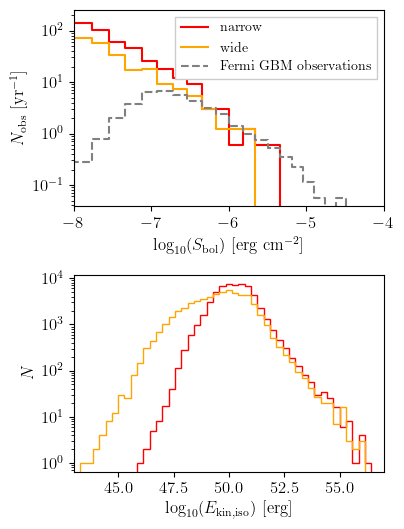

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(4, 6))
fig.subplots_adjust(hspace=0.35)
ax[0].step(narrow_bins[:-1], hist_narrow *0.6, color="red", label="narrow")
ax[0].step(wide_bins[:-1], hist_wide *0.6, color="orange", label="wide")
ax[0].step(fermi_bins[:-1], hist_fermi, color="grey", label="Fermi GBM observations", linestyle="dashed")

#ax[0].hist(log10fluence_wide, cumulative=0, histtype="step", color="orange", bins=bins, label="wide")
ax[0].set(yscale="log", ylabel="$N_{\\rm{obs}}$ [yr$^{-1}$]", xlim=(-8, -4), xlabel="$\\log_{10}(S_{\\rm{bol}})$ [erg cm$^{-2}$]")
ax[0].legend(framealpha=1, fancybox=False, fontsize=10)

ax[1].hist(df_narrow_grb["log10_Ekin_iso"][df_narrow_grb["has_grb"]], histtype="step", color="red", bins=np.linspace(43, 57, 50), cumulative=0)
ax[1].hist(df_wide_grb["log10_Ekin_iso"][df_wide_grb["has_grb"]], histtype="step", color="orange", bins=np.linspace(43, 57, 50), cumulative=0)
ax[1].set(yscale="log", xlim=(43, 57), xlabel="$\\log_{10}(E_{\\rm{kin, iso} })$ [erg]", ylabel="$N$")

fig.savefig("../figures/grb_population.pdf", dpi=250, bbox_inches="tight")

## Calculate the light curves

In [7]:
from fiesta.inference.lightcurve_model import AfterglowFlux

model = AfterglowFlux(name='pbag_gaussian_CVAE',
                  filters=["radio-3GHz", "lsstg", "X-ray-1keV"])


def calculate_afterglow(df_in, p=2.15, log10_epsilon_e=-1, log10_epsilon_B = -3):
    df = df_in.copy()
    
    df["log10_E0"] = np.minimum(57, np.maximum(47, df["log10_Ekin_iso"]))

    df["alphaWing"] = 2*np.ones(df.shape[0])
    df["p"] = p * np.ones(df.shape[0])
    df["log10_epsilon_e"] = log10_epsilon_e * np.ones(df.shape[0])
    df["log10_epsilon_B"] = log10_epsilon_B * np.ones(df.shape[0])
    df["Gamma0"] = 500 * np.ones(df.shape[0])

    grb_parameters = ["inclination_EM", "log10_E0", "thetaCore", "alphaWing", "log10_n0", "p", "log10_epsilon_e", "log10_epsilon_B", "Gamma0", "redshift", "luminosity_distance"]
    params = dict(zip(df[grb_parameters].columns, df[grb_parameters].T.values))
    
    times, mags = model.vpredict(params)

    return times, mags

ERROR:2026-01-21 16:51:11,450:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/enlil/hkoehn/miniconda3/envs/nmma_x_fiesta/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/enlil/hkoehn/miniconda3/envs/nmma_x_fiesta/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/enlil/hkoehn/miniconda3/envs/nmma_x_fiesta/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to

In [7]:
times_narrow, mags_narrow = calculate_afterglow(df_narrow_grb)
times_wide, mags_wide = calculate_afterglow(df_wide_grb)

In [ ]:
mags_narrow["radio-3GHz"][1].shape

In [ ]:
plt.plot(times_narrow[1], mags_narrow["radio-3GHz"][1])

In [77]:
np.sum(df_narrow_grb["has_grb"]) / df_narrow_grb.shape[0]

np.float64(0.6508120649651972)

In [78]:
np.sum(df_wide_grb["has_grb"]) / df_wide_grb.shape[0]

np.float64(0.6531764445917578)

In [ ]:
np.sum(df_narrow_grb["prompt_collapse"] < 4) / df_wide_grb.shape[0]

np.float64(0.8696608109601149)